# Notebook 02: Lake Tahoe Wildfire Clustering

**Obstacle-aware k-means on a geographic dataset**

This notebook applies obstacle-aware k-means to wildfires in the Lake Tahoe basin. The lake acts as a geographic barrier: standard k-means measures distance as straight-line Euclidean distance between $(x, y)$ coordinates, so it can produce clusters that span the water. Obstacle-aware k-means adds an arc-length parameter $s$ along the lake's shoreline as a clustering feature, giving the algorithm a measure of separation along the boundary in addition to straight-line distance between points.

We compare three clusterings: standard k-means as the baseline, obstacle-aware k-means at equal weights (the simplest form of the method, weighting straight-line and shoreline distance equally), and obstacle-aware k-means with the shoreline weight tuned to tighten the clusters along the shore. The distance formula and its weights are introduced where the first obstacle-aware clustering is run.

We test the method at two spatial scales:

- **Basin scale**: all 1,068 wildfires within the TRPA basin.
- **Near-shore scale**: the 296 fires within 1 km of the shoreline, roughly the nearest 27% of the data.

The basin test asks whether the obstacle parameter helps group fires along the shoreline when they're spread across the whole study area. The near-shore test asks how the method behaves when fires are more concentrated near the boundary.

This analysis clusters on spatial features (longitude, latitude, $s$). The attributes fire size and cause are kept in the cleaned dataset so we can check whether the resulting clusters happen to differ in their attribute composition.

## 1. Setup

In [1]:
import os
# Prevent sklearn/KMeans from spawning parallel threads on Windows
# (suppresses OpenMP warning)
os.environ['OMP_NUM_THREADS'] = '1'

# Suppress unecessary integration warnings 
import warnings
from scipy.integrate import IntegrationWarning
warnings.filterwarnings('ignore', category=IntegrationWarning)
warnings.filterwarnings('ignore', message='.*Intel OpenMP.*')

# Standard packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#For querying USGS Hydrography dataset
import requests

# Database access for the FPA FOD wildfire data
import sqlite3

# Reading the TRPA basin boundary (GeoJSON)
import json

# Caching utilities so expensive cells only run once
import pickle
from pathlib import Path

# For polygon operations 
from shapely.geometry import Polygon as ShapelyPolygon, Point

# sklearn baseline and feature scaling
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Our custom package
from obstacle_clustering import SplineBoundary, ObstacleKMeans, attribute_separation
from obstacle_clustering.optimization import objective_function

# --- Plot style ---
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 13,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
})

# Consistent cluster colors across all plots
CLUSTER_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# --- Caching ---
cache_dir = Path('../data/cached')
cache_dir.mkdir(parents=True, exist_ok=True)


def cached_or_run(cache_path, compute_fn, force_rerun=False):
    """Load from cache if it exists, otherwise run compute_fn and save."""
    cache_path = Path(cache_path)
    if cache_path.exists() and not force_rerun:
        print(f'Loading cached: {cache_path.name}')
        with open(cache_path, 'rb') as f:
            return pickle.load(f)
    print(f'Computing (will cache to {cache_path.name})...')
    result = compute_fn()
    with open(cache_path, 'wb') as f:
        pickle.dump(result, f)
    return result


# --- Helpers ---
def arc_length_span(s_values):
    """Calculate the arc-length span of a cluster on the loop [0, 1].

    Span is 1 minus the largest gap between consecutive sorted s-values,
    where the wraparound from 1 back to 0 also counts as a gap. Lower span
    means the cluster's fires are more tightly packed along the shoreline.
    """
    if len(s_values) <= 1:
        return 0.0
    sorted_s = np.sort(s_values)
    gaps = np.diff(sorted_s)
    wrap_gap = (1.0 - sorted_s[-1]) + sorted_s[0]
    largest_gap = max(gaps.max(), wrap_gap)
    return 1.0 - largest_gap


def map_labels_to_reference(labels, reference_labels, k):
    """Map cluster labels so they align with a reference labeling.

    For each new label, finds the reference label it overlaps with most.
    Greedy assignment ensures no two new labels map to the same reference.
    Used here to keep cluster colors consistent across plots and across
    different clustering methods on the same data.
    """
    overlap = np.zeros((k, k), dtype=int)
    for i in range(k):
        for j in range(k):
            overlap[i, j] = np.sum((labels == i) & (reference_labels == j))

    mapping = {}
    used = set()
    sort_order = np.argsort(-overlap.max(axis=1))
    for i in sort_order:
        for j in np.argsort(-overlap[i]):
            if j not in used:
                mapping[i] = j
                used.add(j)
                break
    return mapping

## 2. Querying the USGS National Hydrography Dataset for Lake Tahoe

The NHD's Waterbody (Small Scale) layer returns Lake Tahoe as a single feature with a polygon geometry. We pull the polygon by GNIS name, requesting coordinates in WGS 84, and confirm the feature came back as expected before extracting its vertices in the next cell.

In [2]:
# USGS NHD Waterbody (Small Scale) layer
NHD_WATERBODY_URL = (
    "https://hydro.nationalmap.gov/arcgis/rest/services/nhd/MapServer/10/query"
)

params = {
    'where': "GNIS_NAME = 'Lake Tahoe'",
    'outFields': 'GNIS_NAME,AREASQKM,ELEVATION,REACHCODE', #attributes for check
    'returnGeometry': 'true',
    'outSR': 4326,                          # WGS 84 (lat/lon)
    'f': 'json',
}

response = requests.get(NHD_WATERBODY_URL, params=params)
response.raise_for_status()
data = response.json()

n_features = len(data['features'])
print(f'Features returned: {n_features}')

for feat in data['features']:
    attrs = feat['attributes']
    print(f"  Name:       {attrs['GNIS_NAME']}")
    print(f"  Area:       {attrs['AREASQKM']:.1f} sq km")
    print(f"  Elevation:  {attrs['ELEVATION']:.0f} m")
    print(f"  Reach Code: {attrs['REACHCODE']}")

Features returned: 6
  Name:       Lake Tahoe
  Area:       0.0 sq km
  Elevation:  0 m
  Reach Code: 02080203002790
  Name:       Lake Tahoe
  Area:       0.1 sq km
  Elevation:  0 m
  Reach Code: 03090206073133
  Name:       Lake Tahoe
  Area:       0.1 sq km
  Elevation:  0 m
  Reach Code: 03130005004183
  Name:       Lake Tahoe
  Area:       0.0 sq km
  Elevation:  0 m
  Reach Code: 06010105002593
  Name:       Lake Tahoe
  Area:       0.2 sq km
  Elevation:  0 m
  Reach Code: 07050002001323
  Name:       Lake Tahoe
  Area:       496.9 sq km
  Elevation:  1899 m
  Reach Code: 16050101000339


### Extracting Boundary Coordinates

The geometry is nested as `feature -> geometry -> rings -> [[lon, lat], ...]`. If multiple features come back we take the largest by area; if a single feature has multiple rings, we use the longest ring as the exterior boundary.

In [3]:
# Pick the largest feature if there are multiple
if n_features > 1:
    feat = max(data['features'], key=lambda f: f['attributes']['AREASQKM'])
    print(f"Multiple features found -- using the largest "
          f"({feat['attributes']['AREASQKM']:.1f} sq km)")
else:
    feat = data['features'][0]

rings = feat['geometry']['rings']
print(f'Number of rings: {len(rings)}')
for i, ring in enumerate(rings):
    print(f'  Ring {i}: {len(ring)} vertices')

# Use the longest ring as the exterior boundary
exterior_ring = max(rings, key=len)
coords = np.array(exterior_ring)
lon = coords[:, 0]
lat = coords[:, 1]

print(f'\nExterior ring: {len(lon)} vertices')
print(f'Longitude range: [{lon.min():.4f}, {lon.max():.4f}]')
print(f'Latitude range:  [{lat.min():.4f}, {lat.max():.4f}]')

is_closed = np.allclose(coords[0], coords[-1])
print(f'Ring is closed: {is_closed}')

Multiple features found -- using the largest (496.9 sq km)
Number of rings: 2
  Ring 0: 1528 vertices
  Ring 1: 11 vertices

Exterior ring: 1528 vertices
Longitude range: [-120.1635, -119.9262]
Latitude range:  [38.9286, 39.2489]
Ring is closed: True


### Visualizing the Raw Boundary

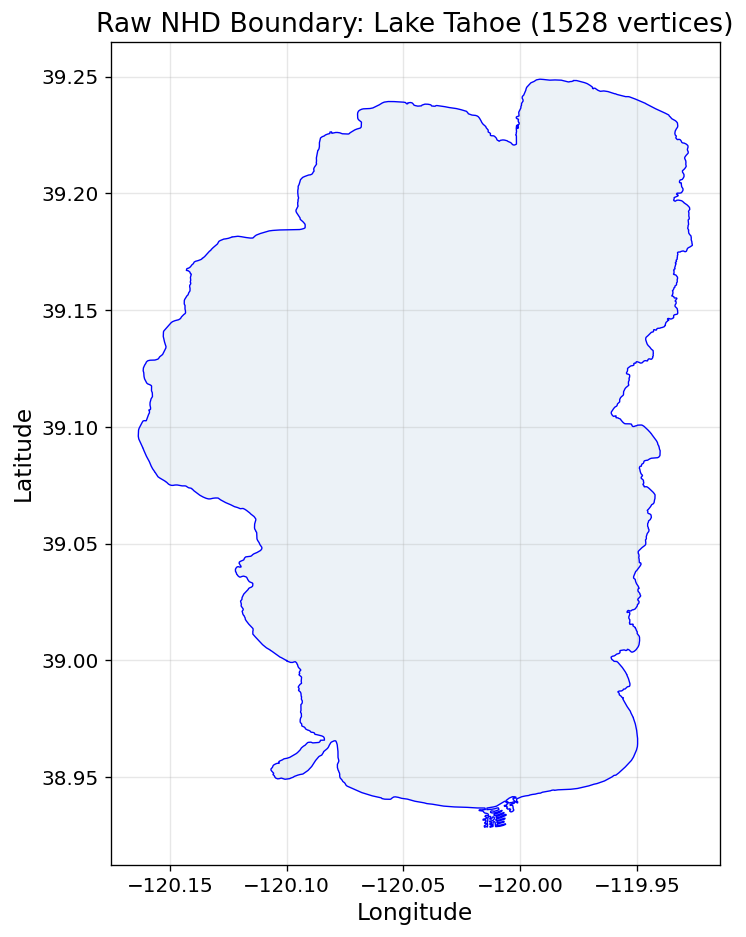

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(lon, lat, 'b-', linewidth=0.8)
ax.fill(lon, lat, alpha=0.1, color='steelblue')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Raw NHD Boundary: Lake Tahoe ({len(lon)} vertices)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Cleaning the Boundary

Two cleanup steps:

1. **Remove the Tahoe Keys**: a marina with channels in the southwest corner of the lake. The NHD polygon traces every channel, which adds detail the cluster boundary doesn't need.
2. **Simplify the remaining shape**: apply Douglas-Peucker simplification with tolerance ~0.0005 degrees (~100 m) to reduce vertex count without losing the lake's geometry.

Tahoe Keys vertices identified: 246
Vertices after clipping: 1282 (removed 246)
Vertices after simplification: 269


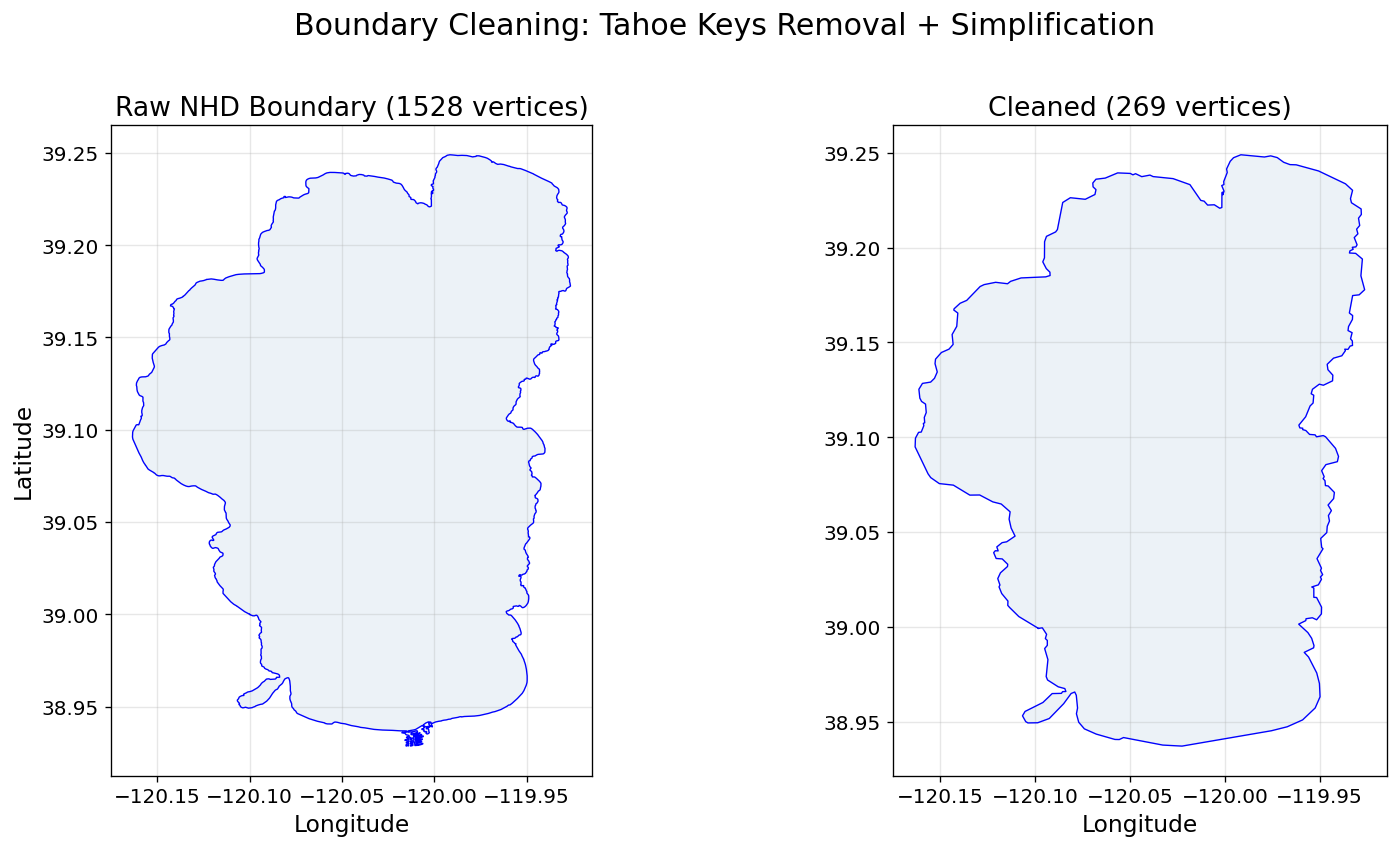


Using cleaned boundary downstream (269 vertices).


In [5]:
# --- Step 1: Remove the Tahoe Keys ---
# The Keys sit in the southern portion of the lake, roughly:
#   latitude < 38.945 and longitude > -120.02
# We drop any vertices inside this box and reconnect the survivors.
keys_mask = (lat < 38.945) & (lon > -120.02)
n_keys = int(np.sum(keys_mask))
print(f'Tahoe Keys vertices identified: {n_keys}')

lon_clipped = lon[~keys_mask]
lat_clipped = lat[~keys_mask]
print(f'Vertices after clipping: {len(lon_clipped)} (removed {n_keys})')

# --- Step 2: Simplify the remaining shape ---
clipped_polygon = ShapelyPolygon(zip(lon_clipped, lat_clipped))
tolerance = 0.0005  # ~100 m at this latitude
simplified = clipped_polygon.simplify(tolerance, preserve_topology=True)

simple_coords = np.array(simplified.exterior.coords)
lon_simple = simple_coords[:, 0]
lat_simple = simple_coords[:, 1]

print(f'Vertices after simplification: {len(lon_simple)}')

# --- Before / After ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

ax = axes[0]
ax.plot(lon, lat, 'b-', linewidth=0.8)
ax.fill(lon, lat, alpha=0.1, color='steelblue')
ax.set_title(f'Raw NHD Boundary ({len(lon)} vertices)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(lon_simple, lat_simple, 'b-', linewidth=0.8)
ax.fill(lon_simple, lat_simple, alpha=0.1, color='steelblue')
ax.set_title(f'Cleaned ({len(lon_simple)} vertices)')
ax.set_xlabel('Longitude')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.suptitle('Boundary Cleaning: Tahoe Keys Removal + Simplification', y=1.01)
plt.tight_layout()
plt.show()

# Replace lon/lat for all downstream cells
lon = lon_simple
lat = lat_simple
print(f'\nUsing cleaned boundary downstream ({len(lon)} vertices).')

### Saving Boundary Coordinates

In [6]:
boundary_dir = Path('../data/boundaries')
boundary_dir.mkdir(parents=True, exist_ok=True)
boundary_path = boundary_dir / 'tahoe_boundary.csv'

boundary_df = pd.DataFrame({'longitude': lon, 'latitude': lat})
boundary_df.to_csv(boundary_path, index=False)

print(f'Saved {len(boundary_df)} boundary points to {boundary_path}')

Saved 269 boundary points to ..\data\boundaries\tahoe_boundary.csv


## 4. Fitting the Spline Boundary

The `SplineBoundary` class fits a closed cubic spline through the boundary vertices. The spline gives a smooth, continuously differentiable representation of the shoreline parameterized by $t \in [0, 1]$. For each fire we'll later compute the closest point on this spline and record both its spline parameter $t$ and its arc-length position $s \in [0, 1]$. 

Total arc length: 1.2027 degrees
Parameter range: (0.0, 1.0)

Start point (t=0): (-120.0983, 38.9991)
End point (t=1):   (-120.0983, 38.9991)
Start matches end: True


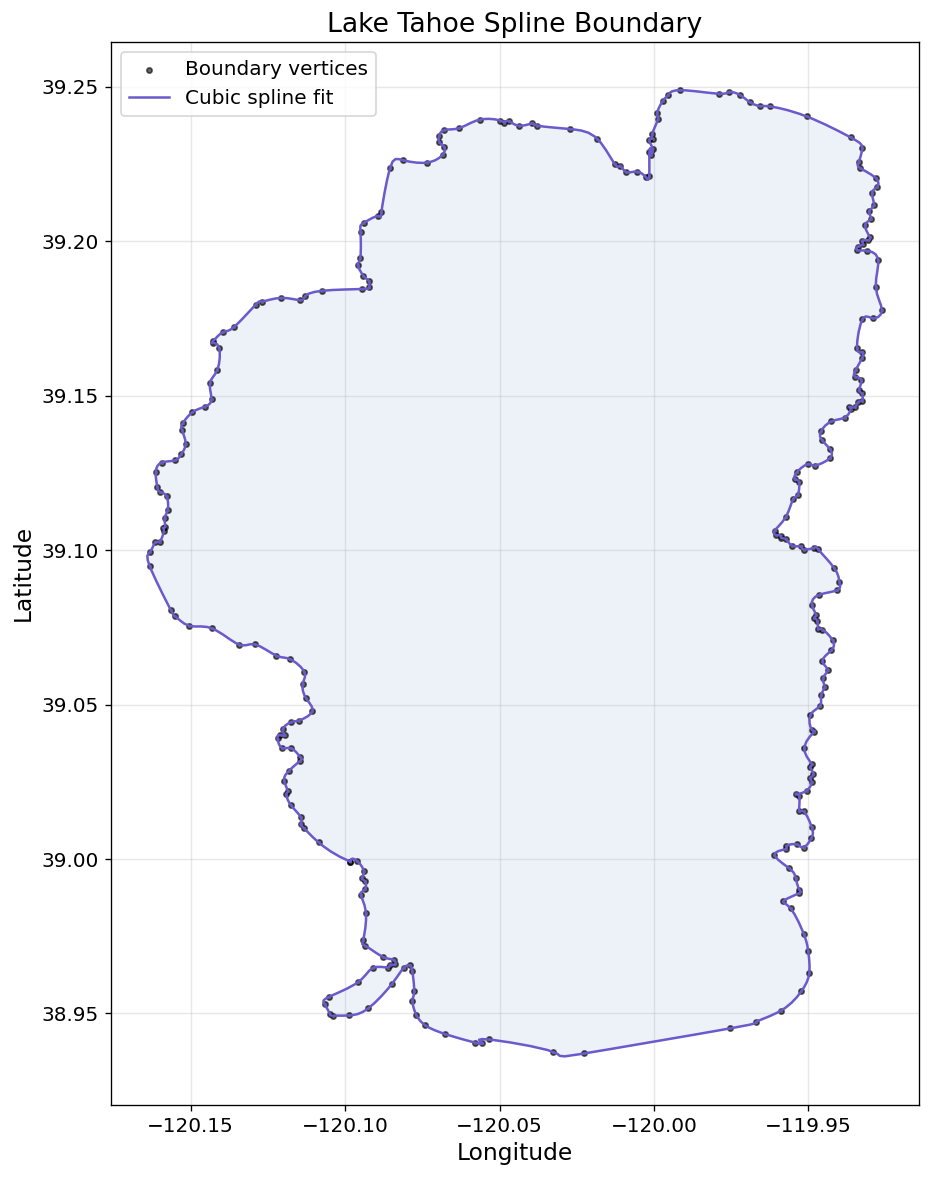

In [7]:
boundary = SplineBoundary(x_coords=lon, y_coords=lat)

L = boundary.total_arc_length()
print(f'Total arc length: {L:.4f} degrees')
print(f'Parameter range: {boundary.t_range()}')

# Verify start and end match (closed loop)
start_pt = boundary.evaluate(0.0)
end_pt = boundary.evaluate(1.0)
print(f'\nStart point (t=0): ({start_pt[0]:.4f}, {start_pt[1]:.4f})')
print(f'End point (t=1):   ({end_pt[0]:.4f}, {end_pt[1]:.4f})')
print(f'Start matches end: {np.allclose(start_pt, end_pt, atol=1e-3)}')

# Sample the spline for visualization
spline_pts = boundary.sample_boundary(n_points=1000)

fig, ax = plt.subplots(figsize=(8, 10))
ax.scatter(lon, lat, c='black', s=10, alpha=0.6, zorder=2, label='Boundary vertices')
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='slateblue', linewidth=1.5,
        zorder=3, label='Cubic spline fit')
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Lake Tahoe Spline Boundary')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Loading Wildfire Data

We pull wildfires from the FPA FOD SQLite database (the USDA Forest Service's Fire Program Analysis Fire-Occurrence Database, a record of US wildfires from 1992 to 2020) within a generous bounding box, then filter to fires inside the TRPA basin polygon (the official boundary of the Tahoe basin used for regulatory and ecological purposes).

The TRPA boundary file should be downloaded from <https://www.tahoeopendata.org/datasets/TRPA::trpa-boundary/about> and placed at `data/raw/trpa_boundary.geojson`.

In [8]:
# --- Load the TRPA basin boundary ---
basin_path = Path('../data/raw/trpa_boundary.geojson')
if not basin_path.exists():
    raise FileNotFoundError(
        f'{basin_path} not found. Download the TRPA Boundary GeoJSON from\n'
        f'https://www.tahoeopendata.org/datasets/TRPA::trpa-boundary/about\n'
        f'and place it at this path.'
    )

with open(basin_path) as f:
    basin_geojson = json.load(f)

basin_coords = basin_geojson['features'][0]['geometry']['coordinates'][0]
basin_polygon = ShapelyPolygon(basin_coords)
print(f'TRPA basin: {len(basin_coords)} vertices')

# --- Query FPA FOD for fires in a bounding box around the basin ---
db_path = '../data/raw/fires.sqlite'

query = """
    SELECT LATITUDE, LONGITUDE, FIRE_SIZE, NWCG_GENERAL_CAUSE,
           NWCG_CAUSE_CLASSIFICATION, FIRE_YEAR, DISCOVERY_DOY
    FROM Fires
    WHERE LATITUDE BETWEEN 38.85 AND 39.35
      AND LONGITUDE BETWEEN -120.25 AND -119.85
"""

with sqlite3.connect(db_path) as conn:
    fires_raw = pd.read_sql_query(query, conn)

# --- Filter to fires inside the TRPA basin polygon ---
fires_raw['_pt'] = fires_raw.apply(
    lambda row: Point(row['LONGITUDE'], row['LATITUDE']), axis=1
)
fires_raw['in_basin'] = fires_raw['_pt'].apply(basin_polygon.contains)

n_before = len(fires_raw)
fires_raw = fires_raw[fires_raw['in_basin']].drop(columns=['_pt', 'in_basin']).copy()
n_after = len(fires_raw)

print(f'Fires in SQL bounding box: {n_before}')
print(f'Fires within TRPA basin:   {n_after}')
print(f'Year range: {fires_raw["FIRE_YEAR"].min()}-{fires_raw["FIRE_YEAR"].max()}')
print(f'\nCause breakdown:')
print(fires_raw['NWCG_GENERAL_CAUSE'].value_counts().to_string())

TRPA basin: 3387 vertices
Fires in SQL bounding box: 1888
Fires within TRPA basin:   1376
Year range: 1992-2020

Cause breakdown:
NWCG_GENERAL_CAUSE
Recreation and ceremony                       391
Missing data/not specified/undetermined       308
Natural                                       204
Smoking                                       166
Arson/incendiarism                             85
Misuse of fire by a minor                      71
Debris and open burning                        65
Equipment and vehicle use                      36
Power generation/transmission/distribution     35
Fireworks                                      10
Other causes                                    5


## 6. Cleaning and Feature Engineering

Three steps:

1. **Drop fires with missing or undetermined cause**. This isn't required for spatial clustering, but it keeps the row set consistent with the cause exploration in section 17.
2. **Encode cause as a binary** (0 = Natural / lightning, 1 = Human-caused). We carry this and the raw fire size on the cleaned data, used for attribute exploration in section 17.
3. **Log-transform fire size**, since the raw distribution is heavily right-skewed (median ~0.1 acres, max in the thousands).

In [9]:
# --- Step 1: Filter out missing/undetermined cause ---
fires = fires_raw[
    fires_raw['NWCG_GENERAL_CAUSE'] != 'Missing data/not specified/undetermined'
].copy().reset_index(drop=True)

print(f'Fires after filtering missing cause: {len(fires)}')

# --- Step 2: Encode cause as binary ---
# 0 = Natural, 1 = Human-caused
fires['cause_binary'] = (fires['NWCG_GENERAL_CAUSE'] != 'Natural').astype(int)


# --- Step 3: Log-transform fire size ---
# Heavy right tail
fires['fire_size_log'] = np.log1p(fires['FIRE_SIZE'].values)

print(f'\nCause classification:')
print(f"  Natural (lightning): {(fires['cause_binary'] == 0).sum()}")
print(f"  Human-caused:        {(fires['cause_binary'] == 1).sum()}")

print(f'\nFire size (acres):')
print(f"  Min:    {fires['FIRE_SIZE'].min():.4f}")
print(f"  Median: {fires['FIRE_SIZE'].median():.2f}")
print(f"  Mean:   {fires['FIRE_SIZE'].mean():.2f}")
print(f"  Max:    {fires['FIRE_SIZE'].max():.2f}")

Fires after filtering missing cause: 1068

Cause classification:
  Natural (lightning): 204
  Human-caused:        864

Fire size (acres):
  Min:    0.0100
  Median: 0.10
  Mean:   10.39
  Max:    4222.00


## 7. Projecting Fires onto the Lake Boundary

For each fire we find the point on the boundary spline closest to it. The result gives us two values per fire:

- $t$ (spline parameter): used internally by `ObstacleKMeans` to evaluate boundary positions during distance calculations.
- $s$ (arc-length parameter, normalized to $[0, 1]$): the clustering feature itself, and the basis for the per-cluster arc-length span metric. It's derived from $t$ but spaced by true distance along the shore, so equal steps in $s$ cover equal stretches of shoreline.

First run can take a few minutes. The result is cached, so reruns are fast.

In [10]:
def project_all_fires():
    print('Projecting fire locations onto lake boundary...')
    lons = fires['LONGITUDE'].values
    lats = fires['LATITUDE'].values
    n = len(fires)

    t_arr = np.zeros(n)
    s_arr = np.zeros(n)
    for idx in range(n):
        if idx % 200 == 0:
            print(f'  {idx}/{n} ({100*idx/n:.0f}%)')
        t_arr[idx], s_arr[idx] = boundary.project_point(lons[idx], lats[idx])
    return t_arr, s_arr


t_values, s_values = cached_or_run(
    cache_dir / 'tahoe_fire_projections.pkl',
    project_all_fires,
)

fires['t_param'] = t_values
fires['s_param'] = s_values

print(f'Projection complete: {len(fires)} fires projected')
print(f's range: [{fires["s_param"].min():.4f}, {fires["s_param"].max():.4f}]')

Loading cached: tahoe_fire_projections.pkl
Projection complete: 1068 fires projected
s range: [0.0069, 0.9980]


## 8. Feature Matrix

The full feature matrix has five columns:

- Columns 0, 1: scaled longitude and latitude (Min-Max to $[0, 1]$)
- Column 2: arc-length parameter $s$ (already in $[0, 1]$)
- Column 3: log-transformed fire size, Min-Max scaled
- Column 4: cause binary (0 or 1)

The clustering uses only the first three columns, the spatial features. Fire size and cause are kept in the matrix but left out of the clustering objective; we look at them separately in section 17.

In [11]:
# Geographic coordinates: Min-Max scale to [0, 1]
scaler_xy = MinMaxScaler()
xy_scaled = scaler_xy.fit_transform(fires[['LONGITUDE', 'LATITUDE']].values)

# Fire size (log): Min-Max scale to [0, 1]
scaler_size = MinMaxScaler()
fire_size_scaled = scaler_size.fit_transform(fires[['fire_size_log']].values)

# Assemble the feature matrix
X = np.column_stack([
    xy_scaled,                          # columns 0, 1: scaled longitude, latitude
    fires['s_param'].values,            # column 2: arc-length parameter
    fire_size_scaled.ravel(),           # column 3: log-scaled fire size
    fires['cause_binary'].values        # column 4: cause type
])

feature_names = ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {feature_names}')

Feature matrix shape: (1068, 5)
Features: ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']


## 9. Basin-Scale Clustering: Standard k-means Baseline

The first method is plain k-means on scaled $(x, y)$ only. We record its mean arc-length span; every obstacle-aware variant that follows is measured against this number.

Before clustering, we pick the number of clusters.

### Choosing the Number of Clusters (Elbow Method)

We use the elbow method to choose $k$. It runs k-means for a range of $k$ values and plots the inertia (within-cluster sum of squared distances) at each. A good $k$ is where the curve bends; adding more clusters beyond that point gives diminishing returns.

c:\Users\mpp24\anaconda3\envs\obstacle-clustering\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


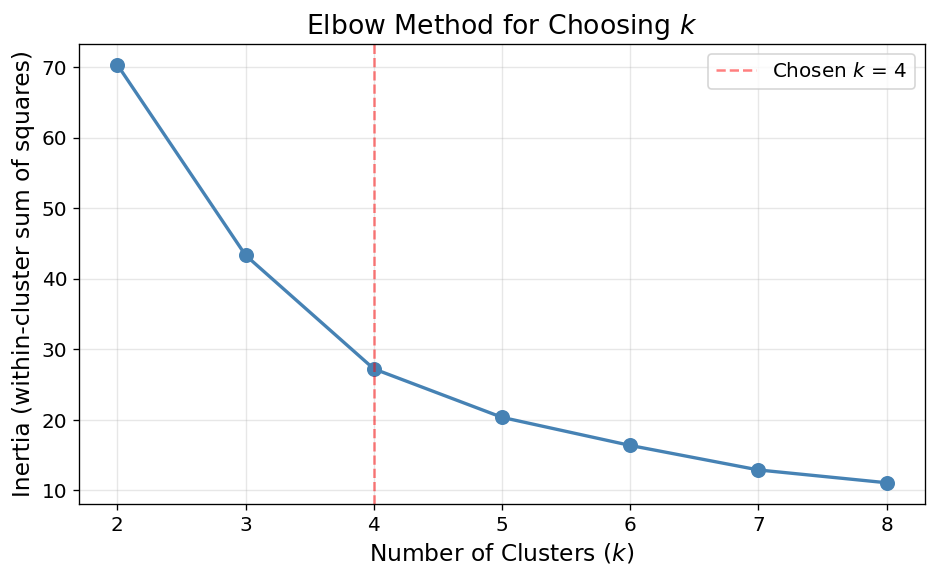

Inertia by k:
  k=2: 70.3290
  k=3: 43.3322
  k=4: 27.2352
  k=5: 20.3613
  k=6: 16.3810
  k=7: 12.9070
  k=8: 11.0922


In [12]:
# Elbow method: test k = 2 through 8
k_range = range(2, 9)
inertias = []

for k_test in k_range:
    km = KMeans(n_clusters=k_test, random_state=42, n_init=10)
    km.fit(xy_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2, markersize=8)

# Mark the chosen k
ax.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='Chosen $k$ = 4')

ax.set_xlabel('Number of Clusters ($k$)')
ax.set_ylabel('Inertia (within-cluster sum of squares)')
ax.set_title('Elbow Method for Choosing $k$')
ax.set_xticks(list(k_range))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the values for reference
print('Inertia by k:')
for k_test, inertia in zip(k_range, inertias):
    print(f'  k={k_test}: {inertia:.4f}')

The inertia curve flattens noticeably after $k = 4$, suggesting four clusters fit the spatial structure well. We use $k = 4$ throughout the rest of the notebook.

### Running the Clustering

We cluster with standard k-means, then calculate each cluster's arc-length span: the shortest stretch of shoreline containing all its fires, as a fraction of the full loop. Then report the mean across the four clusters. This mean arc-length span is the baseline the obstacle-aware variants are compared against.

In [13]:
k = 4 # from the elbow plot above

# Standard k-means on scaled (x, y) only
kmeans_basin = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_basin_std = kmeans_basin.fit_predict(X[:, :2])

# Per-cluster arc-length span, then averaged below for the baseline number
spans_basin_std = [
    arc_length_span(fires['s_param'].values[labels_basin_std == c])
    for c in range(k)
]

print(f'Standard k-means converged in {kmeans_basin.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_basin_std == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_basin_std):.4f}')

Standard k-means converged in 10 iterations

Cluster sizes:
  Cluster 1: 305 fires
  Cluster 2: 230 fires
  Cluster 3: 223 fires
  Cluster 4: 310 fires

Mean arc-length span: 0.2650


## 10. Basin-Scale Clustering: Obstacle-Aware k-means at Equal Weights

Obstacle-aware k-means replaces the straight-line distance with a weighted combination of straight-line distance and distance along the shoreline. Each fire is a feature vector $\mathbf{x} = (\text{geo}, s)$, where $\text{geo} = (x, y)$ is its scaled coordinates and $s$ is its arc-length position along the shoreline. The distance between two fires $\mathbf{x} = (\text{geo}, s)$ and $\mathbf{x}' = (\text{geo}', s')$ is:

$$d^2(\mathbf{x}, \mathbf{x}') = \alpha^2 \, \lVert \text{geo} - \text{geo}' \rVert^2 + \beta^2 \, d_s(s, s')^2$$

The first term is the usual straight-line distance between the scaled coordinates. The second is the distance between the two fires' positions along the shoreline, where $d_s$ measures the shorter way around the loop (so $s = 0.99$ and $s = 0.01$ are close, not far apart). The weight $\alpha$ cales the straight-line term, and $\beta$ scales the shoreline term. Because only the ratio between the weights matters, we hold $\alpha = 1$ throughout and vary $\beta$. Therefore, $\beta = 0$ recovers standard k-means, and larger $\beta$ gives the shoreline more say.

The centroid update changes too. Averaging $s$ directly would be wrong, since it lives on a loop: the mean of $0.99$ and $0.01$ is $0.5$, the far side of the lake. Instead the algorithm averages the cluster's $(x, y)$, projects that mean point onto the boundary, and reads off the $s$ there.

We start at equal weights, $\alpha = \beta = 1$: straight-line and shoreline distance contributing equally before any tuning.

In [16]:
# OA equal weights: pass the 3-column matrix (scaled x, y, s) plus t_data separately.
model_basin_eq = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=0.0, # gamma=0, n_attr=0: no attribute term, spatial features only for this project
    random_state=42, n_attr=0
)
model_basin_eq.fit(X[:, :3], t_data=fires['t_param'].values)
labels_basin_eq = model_basin_eq.labels_

spans_basin_eq = [
    arc_length_span(fires['s_param'].values[labels_basin_eq == c])
    for c in range(k)
]

print(f'OA equal weights: converged in {model_basin_eq.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_basin_eq == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_basin_eq):.4f}')

OA equal weights: converged in 13 iterations

Cluster sizes:
  Cluster 1: 305 fires
  Cluster 2: 236 fires
  Cluster 3: 216 fires
  Cluster 4: 311 fires

Mean arc-length span: 0.2475


## 11. Basin-Scale Clustering: Obstacle-Aware k-means at Optimized $\beta$

Equal weights are a starting point, not necessarily the best choice. To tune $\beta$ we need a way to score a clustering, so we use an objective $J$ that measures within-cluster compactness. For a clustering with centroids $\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_k$:

$$J = \frac{1}{k} \sum_{c=1}^{k} \frac{1}{|C_c|} \sum_{i \in C_c} \left( \lVert \text{geo}_i - \text{geo}_{\mu_c} \rVert^2 + d_s(s_i, s_{\mu_c})^2 \right)$$

The inner sum averages each cluster's squared distances to its centroid, combining the straight-line part in scaled $(x, y)$ with the loop-aware part in $s$; the outer sum averages over the four clusters. Lower $J$ means tighter, more coherent clusters.

A key property is that $J$ is measured in fixed units, with no $\beta$ applied. That makes $J$ values comparable across $\beta$.

We sweep $\beta$ over a 30-point grid from 0.05 to 2.5, holding $\alpha = 1$. At each $\beta$ we record both $J$ and the mean arc-length span. The plot below puts the two on a shared $\beta$ axis so we can see how compactness and shoreline tightness move as $\beta$ changes.

First run can take several minutes. The result is cached, so reruns are fast.

In [28]:
def compute_tahoe_basin_beta_sweep():
    """Sweep beta, recording J (within-cluster distortion) and mean span at each.

    One model fit per beta gives both metrics, so J and span always come from
    the same clustering rather than two separate fits.
    """
    print('Computing Tahoe basin beta sweep (J and span)...')
    n_grid = 30
    beta_vals = np.linspace(0.05, 2.5, n_grid)
    J_vals = np.zeros(n_grid)
    span_vals = np.zeros(n_grid)

    for i, b in enumerate(beta_vals):
        model_b = ObstacleKMeans(
            k=k, boundary=boundary,
            alpha=1.0, beta=b, gamma=0.0,
            random_state=42, n_attr=0
        )
        model_b.fit(X[:, :3], t_data=fires['t_param'].values)

        # J is the model's mean within-cluster distortion (rho_bar):
        # geographic squared distance plus loop-aware s distance, averaged
        # over clusters. No beta is applied, so J is comparable across beta.
        J_vals[i] = model_b.rho_bar_

        # Mean arc-length span from the same fit
        spans_b = [
            arc_length_span(fires['s_param'].values[model_b.labels_ == c])
            for c in range(k)
        ]
        span_vals[i] = np.mean(spans_b)

    return beta_vals, J_vals, span_vals


beta_grid_basin, J_vals_basin, spans_by_beta_basin = cached_or_run(
    cache_dir / 'tahoe_basin_beta_sweep.pkl',
    compute_tahoe_basin_beta_sweep,
)

# Where J is lowest on the grid, for reference (not necessarily our final pick)
i_min_basin = J_vals_basin.argmin()
j_min_beta_basin = beta_grid_basin[i_min_basin]
j_min_J_basin = J_vals_basin[i_min_basin]

print(f'J-minimum on grid: beta = {j_min_beta_basin:.4f}, J = {j_min_J_basin:.4f}')

Loading cached: tahoe_basin_beta_sweep.pkl
J-minimum on grid: beta = 0.8103, J = 0.0307


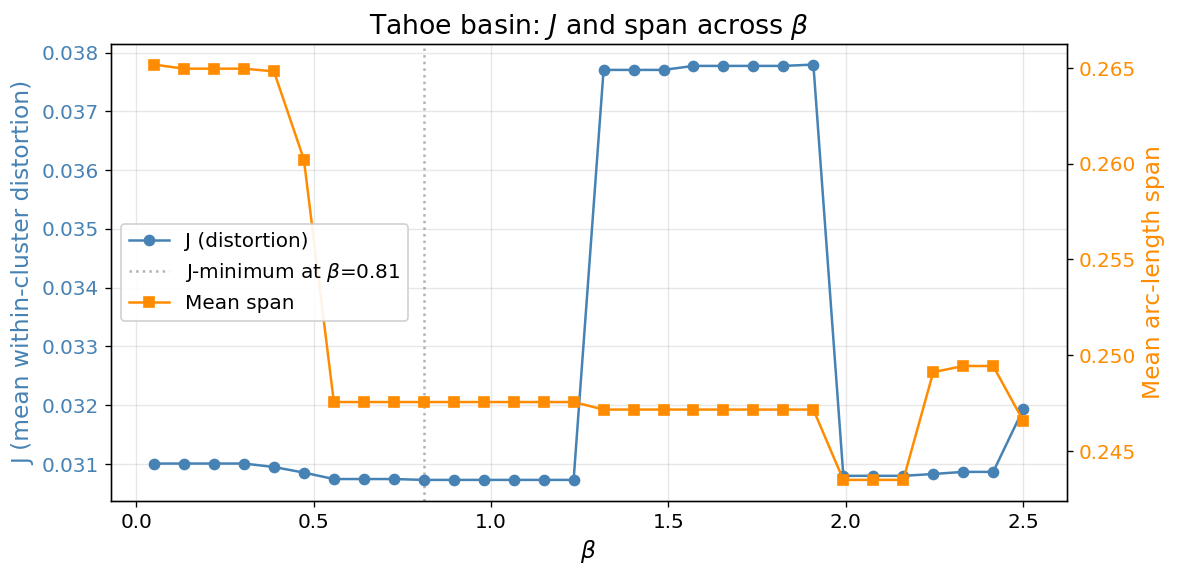

In [ ]:
# Plot the J / span over the 30 beta grid points
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: objective J (within-cluster distortion)
color_J = 'steelblue'
ax1.plot(beta_grid_basin, J_vals_basin, 'o-', color=color_J, label='J (distortion)')
ax1.set_xlabel(r'$\beta$')
ax1.set_ylabel('J (mean within-cluster distortion)', color=color_J)
ax1.tick_params(axis='y', labelcolor=color_J)

# Right axis: mean arc-length span
ax2 = ax1.twinx()
color_span = 'darkorange'
ax2.plot(beta_grid_basin, spans_by_beta_basin, 's-', color=color_span,
         label='Mean span')
ax2.set_ylabel('Mean arc-length span', color=color_span)
ax2.tick_params(axis='y', labelcolor=color_span)

# Mark the J-minimum for reference
ax1.axvline(j_min_beta_basin, color='gray', linestyle=':', alpha=0.6,
            label=rf'J-minimum at $\beta$={j_min_beta_basin:.2f}')

ax1.set_title(r'Tahoe basin: $J$ and span across $\beta$')
ax1.grid(True, alpha=0.3)

# Combine legends from both axes, placed center-left and drawn on top
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
leg = ax2.legend(lines1 + lines2, labels1 + labels2, loc='center left')
leg.set_zorder(10)
leg.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.show()

### Selecting $\beta$ and Refitting

The sweep found the lowest $J$ at $\beta = 0.81$, but the plot tells us to look further. $J$ sits low in two separate basins with a ridge between them, and the two are nearly tied in objective value. Since $J$ doesn't single one out, we break the tie with the span: the basin near $\beta \approx 2.0$ reaches the lowest mean span on the plot, so we select the swept $\beta$ whose $J$ is within a small tolerance of the grid minimum and whose span is smallest. Then, refit at the selected $\beta$.

In [26]:
# Among betas within J_tol of the best J (the low-J basins), pick the smallest span.
J_tol = 0.001
J_best = J_vals_basin.min()
eligible = J_vals_basin <= J_best + J_tol

# Search span only within the low-J betas; everything else set to infinity.
masked_span = np.where(eligible, spans_by_beta_basin, np.inf)
i_sel = masked_span.argmin()
opt_beta_basin = beta_grid_basin[i_sel]

print(f'Selected beta = {opt_beta_basin:.4f} '
      f'(J = {J_vals_basin[i_sel]:.4f}, span = {spans_by_beta_basin[i_sel]:.4f})')

Selected beta = 1.9931 (J = 0.0308, span = 0.2435)


In [30]:
# Refit at the selected beta 
model_basin_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=opt_beta_basin, gamma=0.0,
    random_state=42, n_attr=0
)
model_basin_opt.fit(X[:, :3], t_data=fires['t_param'].values)
labels_basin_opt = model_basin_opt.labels_

spans_basin_opt = [
    arc_length_span(fires['s_param'].values[labels_basin_opt == c])
    for c in range(k)
]

print(f'Optimized beta: {opt_beta_basin:.4f}')
print(f'(J-minimum on grid was at beta = {j_min_beta_basin:.4f})')
print('\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_basin_opt == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_basin_opt):.4f}')

Optimized beta: 1.9931
(J-minimum on grid was at beta = 0.8103)

Cluster sizes:
  Cluster 1: 307 fires
  Cluster 2: 236 fires
  Cluster 3: 311 fires
  Cluster 4: 214 fires

Mean arc-length span: 0.2435


## 12. Aligning Cluster Labels and Plotting the Basin Comparison

k-means assigns cluster IDs arbitrarily, so the same geographic group might be labeled "Cluster 1" in one run and "Cluster 3" in another. We use a greedy overlap-based mapping to relabel the obstacle-aware clusters so they share IDs (and therefore colors) with the standard k-means baseline. This is a visual aid only; it doesn't change the underlying clustering.

In [32]:
# Standard k-means is the reference labeling for the basin
labels_basin_std_aligned = labels_basin_std  # reference by definition

# Align equal-weight and optimized labels to the standard
eq_to_std_basin = map_labels_to_reference(labels_basin_eq, labels_basin_std, k)
labels_basin_eq_aligned = np.array(
    [eq_to_std_basin[l] for l in labels_basin_eq]
)

opt_to_std_basin = map_labels_to_reference(labels_basin_opt, labels_basin_std, k)
labels_basin_opt_aligned = np.array(
    [opt_to_std_basin[l] for l in labels_basin_opt]
)

print('Labels aligned: equal-weight and optimized clusters now share IDs')
print('with the standard k-means baseline.')

Labels aligned: equal-weight and optimized clusters now share IDs
with the standard k-means baseline.


### Side-by-Side Comparison (Basin)

The same 1,068 fires clustered three ways: standard k-means, obstacle-aware at equal weights, and obstacle-aware at the optimized $\beta$. With shared colors from the label alignment, the three panels are directly comparable cluster by cluster.

The differences are subtle at this basin scale. The overall four-way split is stable across all three panels, so adding the shoreline parameter doesn't reorganize the clustering much. The only shift is a difference in cluster assignment among a handful of fires near the borders between clusters.

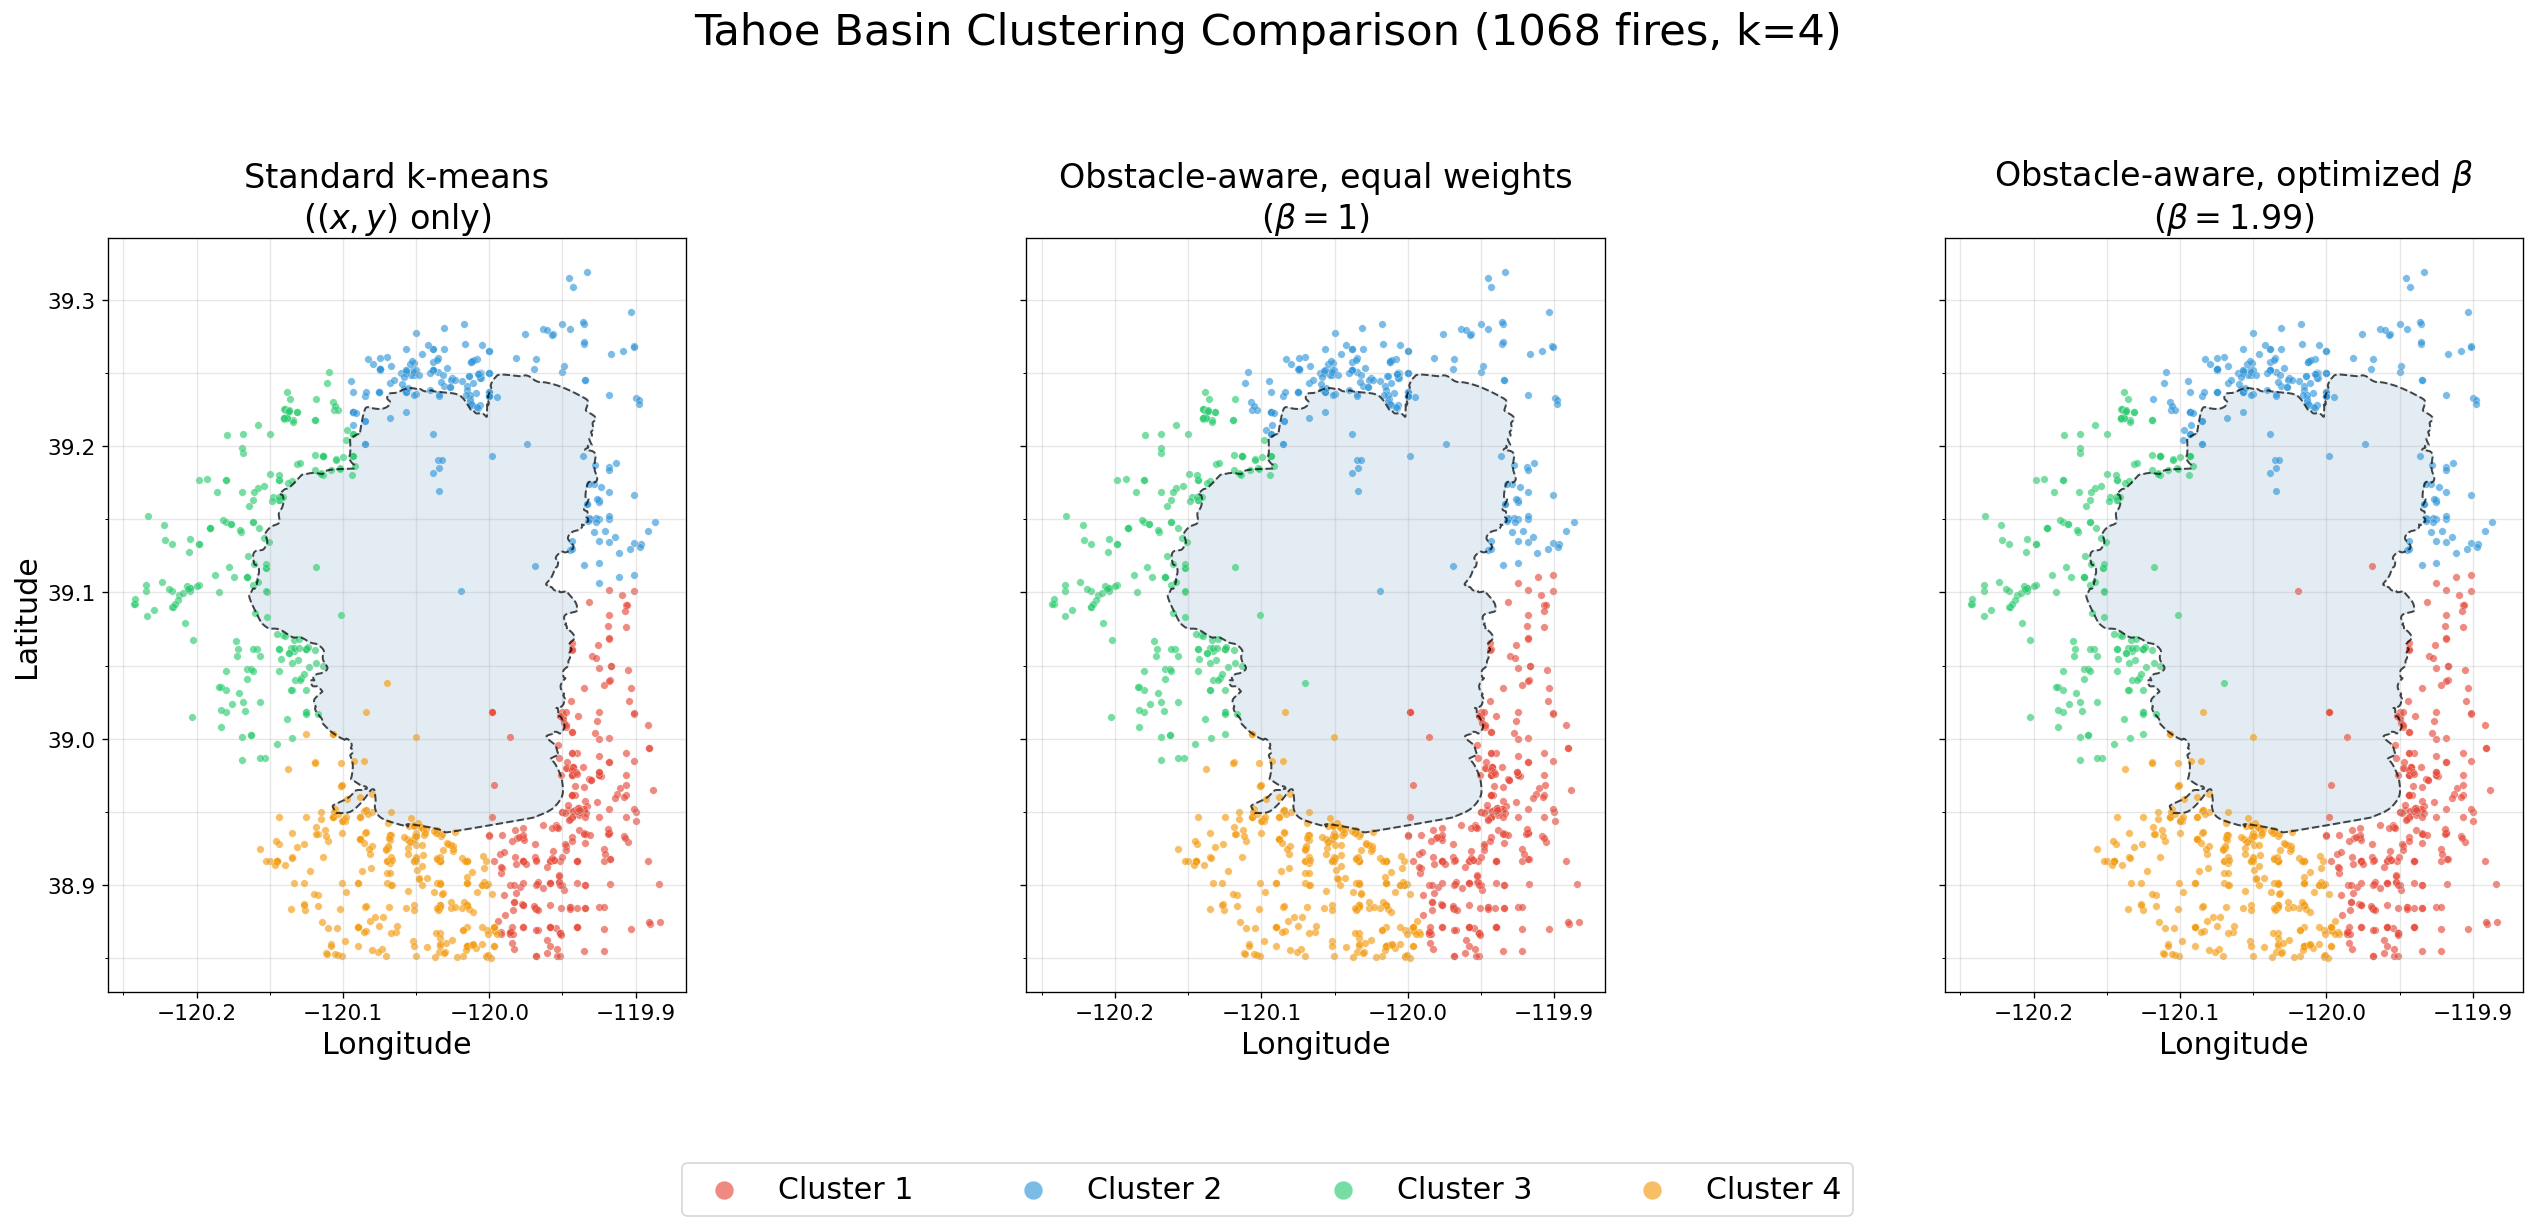

In [52]:
from matplotlib.ticker import MultipleLocator

fig, axes = plt.subplots(1, 3, figsize=(24, 9.5), sharex=True, sharey=True)

for ax, labels, title in [
    (axes[0], labels_basin_std_aligned, 'Standard k-means\n($(x, y)$ only)'),
    (axes[1], labels_basin_eq_aligned,
     r'Obstacle-aware, equal weights' + '\n' + r'($\beta = 1$)'),
    (axes[2], labels_basin_opt_aligned,
     r'Obstacle-aware, optimized $\beta$' + '\n' +
     rf'($\beta = {opt_beta_basin:.2f}$)'),
]:
    # Boundary
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
            linewidth=1.2, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.15, color='steelblue')

    # Fires colored by cluster
    for i in range(k):
        mask = labels == i
        ax.scatter(fires['LONGITUDE'].values[mask],
                   fires['LATITUDE'].values[mask],
                   c=CLUSTER_COLORS[i], s=20, alpha=0.65,
                   label=f'Cluster {i+1}', edgecolors='white', linewidth=0.2)

    ax.set_title(title, fontsize=20)
    ax.set_xlabel('Longitude', fontsize=18)
    ax.set_aspect('equal')

    # Gridlines every 0.05 on both axes; labels only every 0.10 (every other line)
    ax.xaxis.set_major_locator(MultipleLocator(0.10))   # labeled
    ax.xaxis.set_minor_locator(MultipleLocator(0.05))   # gridline only
    ax.yaxis.set_major_locator(MultipleLocator(0.10))   # labeled
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))   # gridline only
    ax.grid(which='both', alpha=0.3)                    # draw both major and minor

    ax.tick_params(axis='both', which='major', labelsize=13)

axes[0].set_ylabel('Latitude', fontsize=18)

# Larger legend, pushed further below the panels
handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, leg_labels, loc='lower center', ncol=k,
           bbox_to_anchor=(0.5, -0.04), frameon=True, fontsize=18,
           markerscale=2.5, columnspacing=3.0, handletextpad=0.8)

fig.suptitle(f'Tahoe Basin Clustering Comparison ({len(fires)} fires, k={k})',
             fontsize=26, y=1.03)

# Reserve bottom room for the legend; pull panels close together
plt.tight_layout(rect=[0, 0.10, 1, 0.97])
plt.subplots_adjust(wspace=0.02)
plt.show()

### Basin Comparison Statistics

In [35]:
span_pct_eq_basin = (
    100 * (np.mean(spans_basin_std) - np.mean(spans_basin_eq))
    / np.mean(spans_basin_std)
)
span_pct_opt_basin = (
    100 * (np.mean(spans_basin_std) - np.mean(spans_basin_opt))
    / np.mean(spans_basin_std)
)

print(f'Lake Tahoe basin clustering comparison ({len(fires)} fires):')
print()
print(f'  Standard k-means on scaled XY:')
print(f'    span = {np.mean(spans_basin_std):.4f}')
print()
print(f'  Obstacle-aware, equal weights (beta = 1, gamma = 0):')
print(f'    span = {np.mean(spans_basin_eq):.4f}')
print(f'    vs standard: span {span_pct_eq_basin:+.1f}%')
print()
print(f'  Obstacle-aware, optimized beta = {opt_beta_basin}:')
print(f'    span = {np.mean(spans_basin_opt):.4f}')
print(f'    vs standard: span {span_pct_opt_basin:+.1f}%')

Lake Tahoe basin clustering comparison (1068 fires):

  Standard k-means on scaled XY:
    span = 0.2650

  Obstacle-aware, equal weights (beta = 1, gamma = 0):
    span = 0.2475
    vs standard: span +6.6%

  Obstacle-aware, optimized beta = 1.993103448275862:
    span = 0.2435
    vs standard: span +8.1%


## 13. Near-Shore Subset

The near-shore subset asks a sharper question: when fires are concentrated near the boundary, does the obstacle parameter help more? We filter to fires within 1 km of the shoreline, computing distance as straight-line from each fire to its boundary projection.

In [36]:
# Compute each fire's straight-line distance to its boundary projection
# (approximate degree-to-km conversion at this latitude, ~39 N)
distances_to_lake_km = np.zeros(len(fires))
for i, t in enumerate(fires['t_param'].values):
    proj = boundary.evaluate(t)
    lon_diff = fires['LONGITUDE'].iloc[i] - proj[0]
    lat_diff = fires['LATITUDE'].iloc[i] - proj[1]
    # At latitude ~39, 1 deg lat ~= 111 km, 1 deg lon ~= 87 km
    distances_to_lake_km[i] = np.sqrt((lon_diff * 87)**2 + (lat_diff * 111)**2)

fires['dist_to_lake_km'] = distances_to_lake_km

# Distance distribution
print('Fire distance distribution (km from Lake Tahoe shore):')
for thr in [1, 2, 5, 10]:
    n = (fires['dist_to_lake_km'] < thr).sum()
    print(f'  Within {thr:2d} km: {n:4d} fires ({100*n/len(fires):.1f}%)')
print(f'  Total: {len(fires)} fires')

# Filter to fires within 1 km of shore
threshold_km = 1
near_mask = fires['dist_to_lake_km'].values < threshold_km
n_near = int(near_mask.sum())

print(f'\nNear-shore subset: {n_near} fires within {threshold_km} km of shore')
print(f'  ~{n_near/k:.0f} fires per cluster at k={k}')

# Subset arrays
X_near = X[near_mask]
t_near = fires['t_param'].values[near_mask]
s_near = fires['s_param'].values[near_mask]
fires_near = fires[near_mask].copy().reset_index(drop=True)

Fire distance distribution (km from Lake Tahoe shore):
  Within  1 km:  296 fires (27.7%)
  Within  2 km:  468 fires (43.8%)
  Within  5 km:  820 fires (76.8%)
  Within 10 km: 1050 fires (98.3%)
  Total: 1068 fires

Near-shore subset: 296 fires within 1 km of shore
  ~74 fires per cluster at k=4


## 14. Near-Shore Clustering: Three Methods

Same three methods as the basin, applied to the near-shore subset.

### 14.1 Standard k-Means (Near-Shore)

In [37]:
kmeans_near = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_near_std = kmeans_near.fit_predict(X_near[:, :2])

spans_near_std = [arc_length_span(s_near[labels_near_std == c]) for c in range(k)]

print(f'Standard k-Means on near-shore subset:')
print(f'  Converged in {kmeans_near.n_iter_} iterations')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_near_std == i)} fires')
print(f'  Mean arc-length span: {np.mean(spans_near_std):.4f}')

Standard k-Means on near-shore subset:
  Converged in 5 iterations
  Cluster 1: 93 fires
  Cluster 2: 71 fires
  Cluster 3: 51 fires
  Cluster 4: 81 fires
  Mean arc-length span: 0.2246


### 14.2 Obstacle-Aware k-Means at Equal Weights (Near-Shore)

In [38]:
model_near_eq = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=0.0,
    random_state=42, n_attr=0
)
model_near_eq.fit(X_near[:, :3], t_data=t_near)
labels_near_eq = model_near_eq.labels_

spans_near_eq = [arc_length_span(s_near[labels_near_eq == c]) for c in range(k)]

print(f'OA equal weights on near-shore subset:')
print(f'  Converged in {model_near_eq.n_iter_} iterations')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_near_eq == i)} fires')
print(f'  Mean arc-length span: {np.mean(spans_near_eq):.4f}')

OA equal weights on near-shore subset:
  Converged in 9 iterations
  Cluster 1: 94 fires
  Cluster 2: 51 fires
  Cluster 3: 71 fires
  Cluster 4: 80 fires
  Mean arc-length span: 0.2261


### 14.3 Obstacle-Aware k-Means at Optimized $\beta$ (Near-Shore)

Same grid-search-and-pick workflow as the basin: sweep $\beta$, plot $J$ alongside span, choose $\beta$.

In [39]:
def compute_tahoe_nearshore_beta_sweep():
    print('Computing Tahoe near-shore objective surface (1D beta sweep)...')
    n_grid = 30
    beta_vals = np.linspace(0.05, 2.0, n_grid)
    J_vals = np.zeros(n_grid)
    for i, b in enumerate(beta_vals):
        J_vals[i] = objective_function(
            (1.0, b, 0.0),
            X_near[:, :3], t_near, boundary,
            k=k, n_attr=0, attr_indices=[], random_state=42
        )
    return beta_vals, J_vals


beta_grid_near, J_vals_near = cached_or_run(
    cache_dir / 'tahoe_nearshore_beta_sweep.pkl',
    compute_tahoe_nearshore_beta_sweep,
)

i_min_near = J_vals_near.argmin()
j_min_beta_near = beta_grid_near[i_min_near]
j_min_J_near = J_vals_near[i_min_near]

print(f'J-minimum on grid: beta = {j_min_beta_near:.4f}, J = {j_min_J_near:.4f}')

Loading cached: tahoe_nearshore_beta_sweep.pkl
J-minimum on grid: beta = 0.9914, J = 1.0194


### $J$ and Span Across $\beta$ (Near-Shore)

Loading cached: tahoe_nearshore_spans_by_beta.pkl


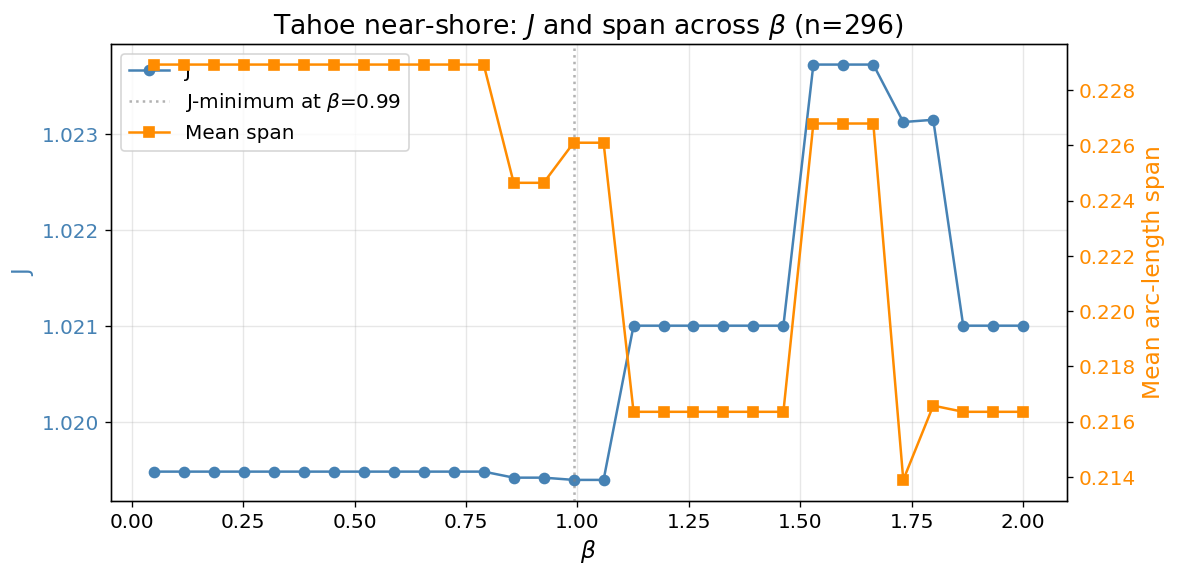

In [40]:
def compute_tahoe_nearshore_spans_by_beta():
    print('Computing Tahoe near-shore mean span at each beta...')
    spans = []
    for b in beta_grid_near:
        model_b = ObstacleKMeans(
            k=k, boundary=boundary,
            alpha=1.0, beta=b, gamma=0.0,
            random_state=42, n_attr=0
        )
        model_b.fit(X_near[:, :3], t_data=t_near)
        spans_b = [arc_length_span(s_near[model_b.labels_ == c]) for c in range(k)]
        spans.append(np.mean(spans_b))
    return np.array(spans)


spans_by_beta_near = cached_or_run(
    cache_dir / 'tahoe_nearshore_spans_by_beta.pkl',
    compute_tahoe_nearshore_spans_by_beta,
)


fig, ax1 = plt.subplots(figsize=(10, 5))

color_J = 'steelblue'
ax1.plot(beta_grid_near, J_vals_near, 'o-', color=color_J, label='J')
ax1.set_xlabel(r'$\beta$')
ax1.set_ylabel('J', color=color_J)
ax1.tick_params(axis='y', labelcolor=color_J)

ax2 = ax1.twinx()
color_span = 'darkorange'
ax2.plot(beta_grid_near, spans_by_beta_near, 's-', color=color_span,
         label='Mean span')
ax2.set_ylabel('Mean arc-length span', color=color_span)
ax2.tick_params(axis='y', labelcolor=color_span)

ax1.axvline(j_min_beta_near, color='gray', linestyle=':', alpha=0.6,
            label=rf'J-minimum at $\beta$={j_min_beta_near:.2f}')

ax1.set_title(rf'Tahoe near-shore: $J$ and span across $\beta$ (n={n_near})')
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()

### Selecting $\beta$ and Refitting (Near-Shore)

Tahoe's near-shore $J$ surface has its minimum at a low $\beta$ value (close to zero -- the algorithm essentially doesn't want $s$ here). We use $\beta = 1.0$ for direct comparability with the basin analysis and the literature convention of equal weights; the resulting clustering is essentially the same as standard k-means on this subset.

In [41]:
# Selected based on the J / span plot above.
# Tahoe near-shore: J wants small beta (s doesn't help here). We use beta=0.97
# for comparability with the basin analysis.
opt_beta_near = 0.99

model_near_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=opt_beta_near, gamma=0.0,
    random_state=42, n_attr=0
)
model_near_opt.fit(X_near[:, :3], t_data=t_near)
labels_near_opt = model_near_opt.labels_

spans_near_opt = [arc_length_span(s_near[labels_near_opt == c]) for c in range(k)]

print(f'Selected beta: {opt_beta_near}')
print(f'(J-minimum on grid was at beta = {j_min_beta_near:.4f})')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_near_opt == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_near_opt):.4f}')

Selected beta: 0.99
(J-minimum on grid was at beta = 0.9914)

Cluster sizes:
  Cluster 1: 94 fires
  Cluster 2: 51 fires
  Cluster 3: 71 fires
  Cluster 4: 80 fires

Mean arc-length span: 0.2261


## 15. Aligning Near-Shore Labels and Plotting

Near-shore clusters are aligned to the basin reference labeling so colors mean the same geographic position (e.g., "Cluster 1" is in the south whether you're looking at the basin or near-shore results).

In [42]:
# Use the basin optimized labels as the reference
ref_labels_near = labels_basin_opt_aligned[near_mask]

std_to_basin_near = map_labels_to_reference(labels_near_std, ref_labels_near, k)
labels_near_std_aligned = np.array(
    [std_to_basin_near[l] for l in labels_near_std]
)

eq_to_basin_near = map_labels_to_reference(labels_near_eq, ref_labels_near, k)
labels_near_eq_aligned = np.array(
    [eq_to_basin_near[l] for l in labels_near_eq]
)

opt_to_basin_near = map_labels_to_reference(labels_near_opt, ref_labels_near, k)
labels_near_opt_aligned = np.array(
    [opt_to_basin_near[l] for l in labels_near_opt]
)

print('Near-shore labels aligned to basin reference.')

Near-shore labels aligned to basin reference.


### Side-by-Side Comparison (Near-Shore)

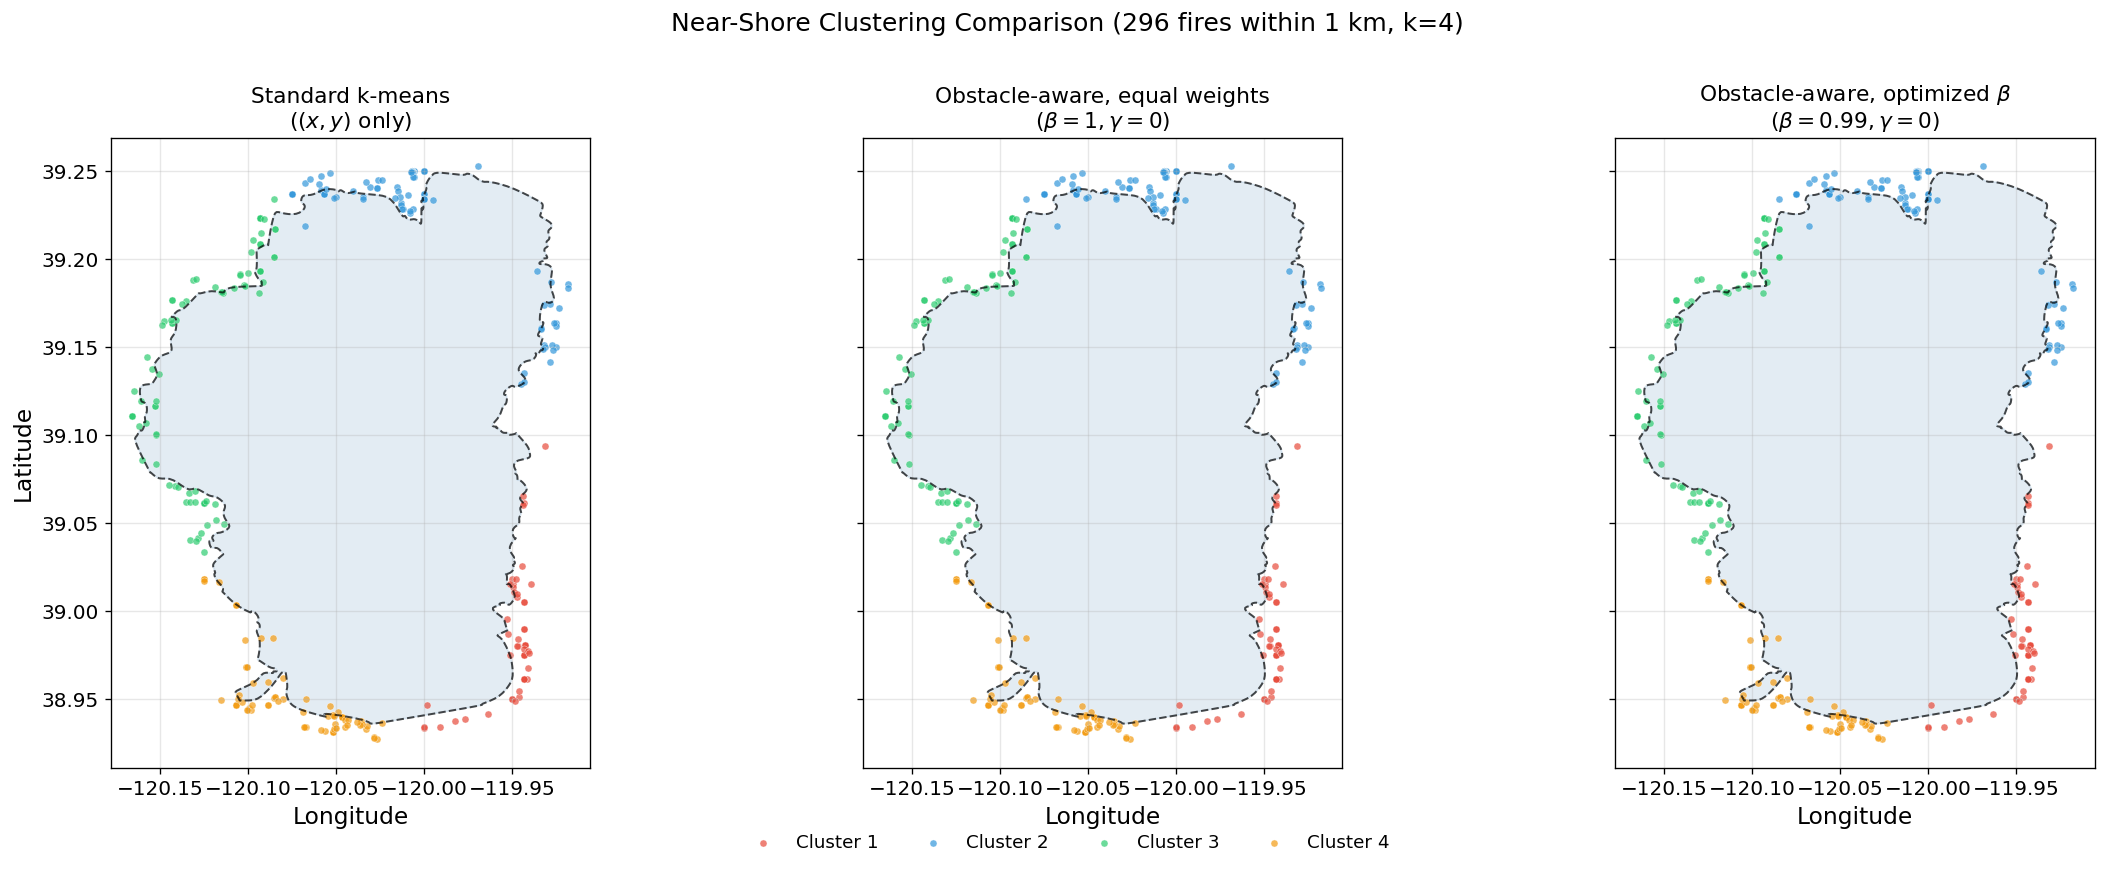

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharex=True, sharey=True)

for ax, labels, title in [
    (axes[0], labels_near_std_aligned, 'Standard k-means\n($(x, y)$ only)'),
    (axes[1], labels_near_eq_aligned,
     r'Obstacle-aware, equal weights' + '\n' + r'($\beta = 1, \gamma = 0$)'),
    (axes[2], labels_near_opt_aligned,
     r'Obstacle-aware, optimized $\beta$' + '\n' +
     rf'($\beta = {opt_beta_near}, \gamma = 0$)'),
]:
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
            linewidth=1.2, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.15, color='steelblue')

    for i in range(k):
        mask = labels == i
        ax.scatter(fires_near['LONGITUDE'].values[mask],
                   fires_near['LATITUDE'].values[mask],
                   c=CLUSTER_COLORS[i], s=18, alpha=0.7,
                   label=f'Cluster {i+1}', edgecolors='white', linewidth=0.3)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Longitude')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Latitude')

handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, leg_labels, loc='lower center', ncol=k,
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=11)

fig.suptitle(
    f'Near-Shore Clustering Comparison '
    f'({n_near} fires within {threshold_km} km, k={k})',
    fontsize=15, y=1.00
)
plt.tight_layout()
plt.show()

### Near-Shore Comparison Statistics

In [44]:
span_pct_eq_near = (
    100 * (np.mean(spans_near_std) - np.mean(spans_near_eq))
    / np.mean(spans_near_std)
)
span_pct_opt_near = (
    100 * (np.mean(spans_near_std) - np.mean(spans_near_opt))
    / np.mean(spans_near_std)
)

print(f'Lake Tahoe near-shore clustering comparison '
      f'({n_near} fires within {threshold_km} km of shore):')
print()
print(f'  Standard k-Means on scaled XY:')
print(f'    span = {np.mean(spans_near_std):.4f}')
print()
print(f'  Obstacle-aware, equal weights (beta = 1, gamma = 0):')
print(f'    span = {np.mean(spans_near_eq):.4f}')
print(f'    vs standard: span {span_pct_eq_near:+.1f}%')
print()
print(f'  Obstacle-aware, optimized beta = {opt_beta_near}:')
print(f'    span = {np.mean(spans_near_opt):.4f}')
print(f'    vs standard: span {span_pct_opt_near:+.1f}%')

Lake Tahoe near-shore clustering comparison (296 fires within 1 km of shore):

  Standard k-Means on scaled XY:
    span = 0.2246

  Obstacle-aware, equal weights (beta = 1, gamma = 0):
    span = 0.2261
    vs standard: span -0.6%

  Obstacle-aware, optimized beta = 0.99:
    span = 0.2261
    vs standard: span -0.6%


## 16. Basin vs. Near-Shore Summary

Putting the two scales side by side. The pattern on Tahoe: $s$ tightens clusters at the basin scale, but adds little when fires are restricted to the near-shore subset. One way to read this: at basin scale, $s$ helps the algorithm distinguish fires that are similar in $(x, y)$ but on opposite sides of the lake; at near-shore scale, fires already share similar XY positions relative to the boundary, so $s$ and XY carry overlapping information and the obstacle parameter doesn't add much.

In [45]:
summary = pd.DataFrame({
    'scale': ['Basin', 'Basin', 'Near-shore', 'Near-shore'],
    'method': ['Standard k-means', 'OA (beta=1)', 'Standard k-means', 'OA (beta=1)'],
    'n_fires': [len(fires), len(fires), n_near, n_near],
    'mean_span': [
        np.mean(spans_basin_std), np.mean(spans_basin_opt),
        np.mean(spans_near_std), np.mean(spans_near_opt),
    ],
    'span_improvement_pct': [
        0.0,
        span_pct_opt_basin,
        0.0,
        span_pct_opt_near,
    ],
})

print('Lake Tahoe clustering summary:')
print(summary.to_string(index=False))

Lake Tahoe clustering summary:
     scale           method  n_fires  mean_span  span_improvement_pct
     Basin Standard k-means     1068   0.264962              0.000000
     Basin      OA (beta=1)     1068   0.243482              8.107018
Near-shore Standard k-means      296   0.224648              0.000000
Near-shore      OA (beta=1)      296   0.226099             -0.645896


## 17. Exploratory: Did the Clustering Inadvertently Separate Fires by Attribute?

We didn't cluster on fire size or cause -- the analysis used only $(x, y)$ and $s$. But it's worth asking whether the geographic clusters we found happen to differ in their attribute composition. This is exploratory and curiosity-driven; it's not a finding the methodology is designed to produce.

We use $\sigma_a$ (attribute separation score) which combines a Kruskal-Wallis test on continuous attributes and a Chi-squared test on categorical attributes. Higher values mean cluster membership is more predictive of the attribute.

In [46]:
# Sigma_a uses the cluster labels and the full feature matrix.
# attr_indices=[3, 4] points to fire_size and cause_binary.
sigma_basin_std, _ = attribute_separation(X, labels_basin_std, k, attr_indices=[3, 4])
sigma_basin_opt, _ = attribute_separation(X, labels_basin_opt, k, attr_indices=[3, 4])

print('Attribute separation (sigma_a) for basin clusterings:')
print(f'  Standard k-means:           {sigma_basin_std:.4f}')
print(f'  OA (beta = {opt_beta_basin}):              {sigma_basin_opt:.4f}')

Attribute separation (sigma_a) for basin clusterings:
  Standard k-means:           0.0833
  OA (beta = 1.993103448275862):              0.0833


### Cluster Composition

For the obstacle-aware basin clustering, what's the mix of human-caused vs. natural fires in each cluster? And what's the median fire size?

In [47]:
# Build a per-cluster composition table for the basin OA clustering
fires['cluster_basin_opt'] = labels_basin_opt_aligned

comp_rows = []
for cluster_id in range(k):
    sub = fires[fires['cluster_basin_opt'] == cluster_id]
    comp_rows.append({
        'cluster': cluster_id + 1,
        'n_fires': len(sub),
        'pct_human': 100 * (sub['cause_binary'] == 1).mean(),
        'pct_natural': 100 * (sub['cause_binary'] == 0).mean(),
        'median_fire_size': sub['FIRE_SIZE'].median(),
        'mean_fire_size': sub['FIRE_SIZE'].mean(),
    })

composition = pd.DataFrame(comp_rows)
print('Cluster composition (obstacle-aware, basin):')
print(composition.to_string(index=False))

Cluster composition (obstacle-aware, basin):
 cluster  n_fires  pct_human  pct_natural  median_fire_size  mean_fire_size
       1      307  75.895765    24.104235               0.1        2.508371
       2      236  80.932203    19.067797               0.1       27.911017
       3      214  79.439252    20.560748               0.1        1.390748
       4      311  86.816720    13.183280               0.1       11.051576


The composition table will show whether the four geographic clusters happen to differ in their human-vs-natural mix or their typical fire size. For Tahoe, the lake's south shore historically has higher human-caused fire density (more recreation use), so we'd expect some pattern even without intentionally clustering on cause. Any differences here are descriptive observations, not methodological claims about the obstacle-aware algorithm.

## 18. Saving Cluster Assignments

We save the cleaned dataset with cluster labels from all three methods. This is for downstream use (other notebooks, GitHub release, etc.); the dashboard built in Notebook 04 uses Lake Mead's results, not Tahoe's.

In [48]:
# Add the rest of the cluster labels to the fires DataFrame
fires['cluster_basin_std'] = labels_basin_std_aligned
fires['cluster_basin_eq'] = labels_basin_eq_aligned
# cluster_basin_opt was already added above for the composition table

# Near-shore labels: NaN for fires outside the subset
fires['cluster_near_std'] = np.nan
fires['cluster_near_eq'] = np.nan
fires['cluster_near_opt'] = np.nan
fires.loc[near_mask, 'cluster_near_std'] = labels_near_std_aligned
fires.loc[near_mask, 'cluster_near_eq'] = labels_near_eq_aligned
fires.loc[near_mask, 'cluster_near_opt'] = labels_near_opt_aligned

# Save to processed data directory
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)
fires_path = processed_dir / 'tahoe_fires_clustered.csv'
fires.to_csv(fires_path, index=False)

print(f'Saved {len(fires)} clustered fires to:')
print(f'  {fires_path}')

Saved 1068 clustered fires to:
  ..\data\processed\tahoe_fires_clustered.csv


## 19. Summary

Tahoe's results in brief:

- **Basin scale**: obstacle-aware k-means improves arc-length span by ~7% over standard k-means at $\beta = 1$. The $J$ surface has a clean minimum near equal weights, so no tuning is needed.
- **Near-shore scale**: at $\beta = 1$, obstacle-aware clustering produces essentially the same result as standard k-means; span improvement is near zero. The $J$ surface here prefers $\beta$ close to zero, indicating the algorithm doesn't want the obstacle parameter on this subset.

Tahoe's roughly round geometry plays a role here: fires on opposite shores are already far apart in straight-line distance, so the lake doesn't create the kind of "close in XY but far across the obstacle" ambiguity that the boundary parameter is designed to resolve. We pick this back up in Notebook 03, which applies the same method to Lake Mead -- a much longer, narrower waterbody with a different result.